In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gzip
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# path to the series matrix file
path = "/content/drive/MyDrive/GSE6613_series_matrix.txt.gz"

# loading the data
df = pd.read_csv(path, sep="\t", comment="!", index_col=0, compression = "gzip")

df.head()

,GSM153404,GSM153405,GSM153406,GSM153407,GSM153408,GSM153409,GSM153410,GSM153411,GSM153412,GSM153413,...,GSM153499,GSM153500,GSM153501,GSM153502,GSM153503,GSM153504,GSM153505,GSM153506,GSM153507,GSM153508
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,114.5,105.1,145.7,168.7,94.3,96.2,155.8,99.8,100.9,106.4,...,153.8,103.7,132.8,195.5,82.6,28.2,163.9,29.0,104.8,32.8
1053_at,64.4,58.4,52.5,45.4,51.3,50.7,42.2,6.7,44.0,55.5,...,44.0,70.5,61.9,52.2,61.2,67.6,101.9,46.8,74.9,78.1
117_at,206.3,179.8,192.0,263.6,211.9,149.5,157.3,216.6,230.5,224.1,...,268.9,48.6,193.6,132.5,165.5,146.0,291.4,246.2,251.2,210.0
121_at,507.0,497.8,346.3,430.7,485.5,437.6,424.1,678.7,434.1,592.8,...,403.6,559.1,569.7,532.8,525.7,603.9,479.7,271.9,506.1,270.4
1255_g_at,34.5,18.0,40.1,40.5,22.8,6.4,27.4,5.2,34.7,18.6,...,44.8,39.5,30.5,65.8,54.3,19.3,61.0,40.8,29.5,82.2


In [4]:
def get_characteristics(matrix_file, prefix):
    """
    Reads the matrix file and returns the line containing the sample conditions.

    Args:
        matrix_file (str): The path to the matrix file.
        prefix (str): The phrase to search for the sample condition metadata.

    Returns:
        str or None: The sample conditions, or None if not found.
    """

    opener = gzip.open if matrix_file.endswith(".gz") else open

    sample_conditions = []
    with opener(matrix_file, 'rt', encoding = 'utf-8', errors = 'replace') as file:
        for line in file:
            line = line.rstrip("\n")
            if line.startswith(prefix):
                rest = line[len(prefix):].strip()
                rest = rest.lstrip(":= \t")        # removing any leading punctuation (colon or equals) if exists
                if rest:
                    labels = rest.split('\t')
                    for i in labels:
                        sample_conditions.append(i.strip('"'))
    return sample_conditions

prefix = '!Sample_characteristics_ch1'
labels_raw = get_characteristics(path, prefix)
print(labels_raw)

["Parkinson's disease", 'healthy control', 'healthy control', "Parkinson's disease", "Parkinson's disease", 'neurological disease control', "Parkinson's disease", "Parkinson's disease", "Parkinson's disease", "Parkinson's disease", "Parkinson's disease", "Parkinson's disease", "Parkinson's disease", "Parkinson's disease", "Parkinson's disease", 'healthy control', "Parkinson's disease", "Parkinson's disease", "Parkinson's disease", 'healthy control', "Parkinson's disease", 'healthy control', 'neurological disease control', 'healthy control', 'healthy control', 'healthy control', "Parkinson's disease", 'neurological disease control', "Parkinson's disease", 'healthy control', "Parkinson's disease", "Parkinson's disease", "Parkinson's disease", "Parkinson's disease", 'neurological disease control', "Parkinson's disease", 'neurological disease control', "Parkinson's disease", "Parkinson's disease", "Parkinson's disease", 'healthy control', "Parkinson's disease", "Parkinson's disease", 'neur

**Note:** Logistic regression will be performed on the data,since the model will be used to predict categorical outputs.

###**Binary logistic regression**
Simply encoding the data into presence or absence of PD

In [5]:
# Encoding the PD condition as 1 and controls as 0

encoded_condition = []
for x in list(labels_raw):
    s = str(x).lower()
    if "parkinson" in s:
        encoded_condition.append(1)
    else:
        # both "neurological disease control" and "healthy control" fall here
        encoded_condition.append(0)

y = np.array(encoded_condition)   # storing the conditions as target
np.unique(y, return_counts=True)

(array([0, 1]), array([55, 50]))

In [6]:
# Storing the sample IDs
sample_ids = [s for s in df.columns if s.startswith("GSM")]

# Obtaining the expression values for each sample, maintaining the order of sample IDs

expr = df.copy()
expr = expr.T                # transposing so rows are samples, cols are probes/genes
expr = expr.loc[sample_ids]  # match same sample order

In [7]:
# Coercing expression values to numeric values only
expr_numeric = expr.apply(pd.to_numeric, errors='coerce')

# Checking to see if the error after coercion is too large due to data drop

before = expr.shape[1]
after  = expr_numeric.dropna(axis=1, how='any').shape[1]
print(before, after, 1 - after/before)

# Imputing the value using median, if data loss very huge
# expr_numeric = expr_numeric.fillna(expr_numeric.median())

22283 22283 0.0


In [8]:
# Dropping all NA and invalid columns, since data loss is not large (<1% probes)
expr_numeric = expr_numeric.dropna(axis=1, how='any')
print(expr_numeric)
X = expr_numeric.values   # storing the gene expression values as features

ID_REF     1007_s_at  1053_at  117_at  121_at  1255_g_at  1294_at  1316_at  \
GSM153404      114.5     64.4   206.3   507.0       34.5    135.3     75.1   
GSM153405      105.1     58.4   179.8   497.8       18.0    139.1     51.2   
GSM153406      145.7     52.5   192.0   346.3       40.1    163.8     72.0   
GSM153407      168.7     45.4   263.6   430.7       40.5    183.9     54.7   
GSM153408       94.3     51.3   211.9   485.5       22.8    138.9     83.0   
...              ...      ...     ...     ...        ...      ...      ...   
GSM153504       28.2     67.6   146.0   603.9       19.3    128.6     81.0   
GSM153505      163.9    101.9   291.4   479.7       61.0    159.8     58.3   
GSM153506       29.0     46.8   246.2   271.9       40.8    156.9     44.2   
GSM153507      104.8     74.9   251.2   506.1       29.5    241.2     95.4   
GSM153508       32.8     78.1   210.0   270.4       82.2    105.2     93.7   

ID_REF     1320_at  1405_i_at  1431_at  ...  AFFX-r2-Hs28SrRNA-

In [9]:
# Data training

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, probs)
print(f"AUC value = {auc:.2f}")

acc = accuracy_score(y_test, model.predict(X_test)) * 100
print(f"Logistic Regression model accuracy: {acc:.2f}%")

report = classification_report(y_test, model.predict(X_test))
print(f"Classification report: \n{report}")

AUC value = 0.71
Logistic Regression model accuracy: 71.43%
Classification report: 
              precision    recall  f1-score   support

           0       0.78      0.64      0.70        11
           1       0.67      0.80      0.73        10

    accuracy                           0.71        21
   macro avg       0.72      0.72      0.71        21
weighted avg       0.72      0.71      0.71        21



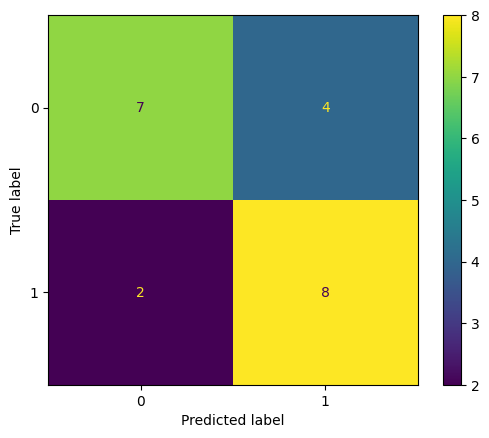

In [10]:
# Displaying the confusion matrix to assess model performance visually

cm = confusion_matrix(y_test, model.predict(X_test))
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.show()

This model seems to be biased towards underpredicting PD patients than overpredicting.

###**Multinomial regression**

In [11]:
# encoding the target
encoded_condition_multinom = []

for x in labels_raw:
  s = x.lower()
  if 'parkinson' in s:
    encoded_condition_multinom.append(1)
  elif 'neurological' in s:
    encoded_condition_multinom.append(2)
  else:
    encoded_condition_multinom.append(0)

y_multinom = np.array(encoded_condition_multinom)
np.unique(y_multinom, return_counts = True)

(array([0, 1, 2]), array([22, 50, 33]))

In [12]:
# Data training

X_train_multinom, X_test_multinom, y_train_multinom, y_test_multinom = train_test_split(X, y_multinom, test_size = 0.2, stratify = y_multinom, random_state = 42)

In [13]:
model_multinom = LogisticRegression(multi_class = 'multinomial', class_weight = 'balanced', max_iter = 2000)
model_multinom.fit(X_train_multinom, y_train_multinom)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=2000,
                   multi_class='multinomial')

In [14]:
probs_multinom = model_multinom.predict_proba(X_test_multinom)

In [15]:
auc_multinom = roc_auc_score(y_test_multinom, probs_multinom, multi_class = 'ovr')
acc_multinom = accuracy_score(y_test_multinom, model_multinom.predict(X_test_multinom))*100
report_multinom = classification_report(y_test_multinom, model_multinom.predict(X_test_multinom))

print(f'Multinomial regression metrics:')
print(f'AUC score: {auc_multinom:.2f}')
print(f'Accuracy score: {acc_multinom:.2f}%')
print(f'Classification report: \n{report_multinom}')

Multinomial regression metrics:
AUC score: 0.74
Accuracy score: 61.90%
Classification report: 
              precision    recall  f1-score   support

           0       0.40      0.50      0.44         4
           1       0.69      0.90      0.78        10
           2       0.67      0.29      0.40         7

    accuracy                           0.62        21
   macro avg       0.59      0.56      0.54        21
weighted avg       0.63      0.62      0.59        21



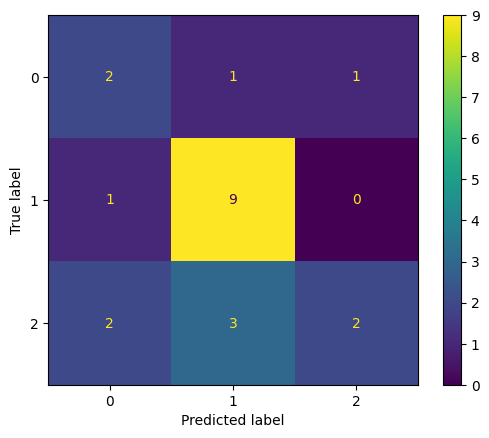

In [16]:
cm_multinom = confusion_matrix(y_test_multinom, model_multinom.predict(X_test_multinom))
disp_cm_multinom = ConfusionMatrixDisplay(cm_multinom)

disp_cm_multinom.plot()
plt.show()

The multinomial model is failing to successfully differentiate between the control classes. This is seen with the stable AUC score but significantly reduced accuracy. It is also observable in the confusion matrix, where the PD patients are being predicted much better than the other classes.
There seems to be a larger number of other neurological diseased controls predicted as PD samples.
Having three categories of disease condition is confusing the model more than having a binomial classification.

####**Comparing top contributing genes**

In [17]:
# Pulling the coefficients for PD
pd_weights_multinom = model_multinom.coef_[1]

# Getting gene names
gene_names = expr_numeric.columns

# Creating a DataFrame to link genes to their 'importance' weights
importance_df_multinom = pd.DataFrame({'Gene': gene_names, 'Weight': pd_weights_multinom})

In [18]:
# Getting the top 10 genes contributing to PD prediction
upreg_pd_genes_multinom = importance_df_multinom.sort_values(by = 'Weight', ascending = False)
downreg_pd_genes_multinom = importance_df_multinom.sort_values(by = 'Weight', ascending = True)

print(f'Multinomial regression \n\n')
print(f'Top 10 upregulated genes: \n{upreg_pd_genes_multinom.head(10)}')
print(f'Top 10 downregulated genes: \n{downreg_pd_genes_multinom.head(10)}')

Multinomial regression 


Top 10 upregulated genes: 
              Gene    Weight
3544   204018_x_at  0.001105
13705  214327_x_at  0.001043
1436     201909_at  0.000848
432    200905_x_at  0.000785
11096  211696_x_at  0.000747
3533     204007_at  0.000662
13310  213932_x_at  0.000661
268    200741_s_at  0.000634
21059  221700_s_at  0.000632
8633   209140_x_at  0.000546
Top 10 downregulated genes: 
                       Gene    Weight
12466           213084_x_at -0.000816
10933           211528_x_at -0.000769
22267  AFFX-r2-Ec-bioD-3_at -0.000764
13792           214414_x_at -0.000751
8328            208834_x_at -0.000684
11298           211911_x_at -0.000660
6084            206559_x_at -0.000645
10964           211560_s_at -0.000622
3061              203535_at -0.000613
4374            204848_x_at -0.000609


In [19]:
# For binomial regression;
pd_weights = model.coef_[0]

importance_df = pd.DataFrame({'Gene': gene_names, 'Weight': pd_weights})

In [20]:
upreg_pd_genes = importance_df.sort_values(by = 'Weight', ascending = False)
downreg_pd_genes = importance_df.sort_values(by = 'Weight', ascending = True)

print(f'Binomial regression: \n\n')
print(f'Top 10 upregulated genes: \n{upreg_pd_genes.head(10)}')
print(f'Top 10 downregulated genes: \n{downreg_pd_genes.head(10)}')

Binomial regression: 


Top 10 upregulated genes: 
                 Gene    Weight
12895     213515_x_at  0.002393
22222  AFFX-CreX-3_at  0.001978
13705     214327_x_at  0.001813
1436        201909_at  0.001813
2445      202917_s_at  0.001688
453         200926_at  0.001560
21059     221700_s_at  0.001419
11327     211940_x_at  0.001415
15602     216231_s_at  0.001401
11096     211696_x_at  0.001328
Top 10 downregulated genes: 
              Gene    Weight
8319   208825_x_at -0.002578
8328   208834_x_at -0.002164
4374   204848_x_at -0.002144
10933  211528_x_at -0.001670
11298  211911_x_at -0.001663
3061     203535_at -0.001639
15895  216526_x_at -0.001566
2635   203107_x_at -0.001419
6084   206559_x_at -0.001299
8950   209458_x_at -0.001280


###**Random forest classifier**

In [21]:
rf_model = RandomForestClassifier(n_estimators = 100, class_weight = 'balanced', random_state = 42)
rf_model.fit(X_train_multinom, y_train_multinom)

# Extracting feature importance
rf_importance_df = pd.DataFrame({'Gene':gene_names, 'RF_importance':rf_model.feature_importances_})

In [22]:
# Extracting top genes contributing to PD predictions

genes_rf = rf_importance_df.sort_values(by = 'RF_importance', ascending = False)

print(f'Top 20 upregulated genes by rf weight: \n{genes_rf.head(20)}')

Top 20 upregulated genes by rf weight: 
              Gene  RF_importance
8209     208715_at       0.004759
4600     205074_at       0.004501
13528  214150_x_at       0.004490
6203     206678_at       0.003836
8353   208859_s_at       0.003773
8480   208987_s_at       0.003381
4891     205365_at       0.003338
9063   209574_s_at       0.003316
19220    219857_at       0.003266
17865    218501_at       0.003219
14694    215321_at       0.003099
2268     202741_at       0.003082
9393   209908_s_at       0.002993
8232   208738_x_at       0.002968
8337   208843_s_at       0.002901
11522    212137_at       0.002821
7247   207727_s_at       0.002784
4434   204908_s_at       0.002758
22139     59705_at       0.002742
20652  221290_s_at       0.002728


In [23]:
lr_top_200_genes = list(upreg_pd_genes_multinom['Gene'].head(100)) + list(downreg_pd_genes_multinom['Gene'].head(100))

rf_top_200_genes = list(genes_rf['Gene'].head(200))

common_genes = set(lr_top_200_genes).intersection(set(rf_top_200_genes))

print(f'No. of common genes: {len(common_genes)}')
print(f'Shared genes: {common_genes}')

No. of common genes: 4
Shared genes: {'200926_at', '217984_at', '204446_s_at', '210434_x_at'}


In [24]:
# Common genes with the binomial regression model

binr_top_200_genes = list(upreg_pd_genes['Gene'].head(100)) + list(downreg_pd_genes['Gene'].head(100))

common_genes_binr = set(binr_top_200_genes).intersection(set(rf_top_200_genes))

print(f'No. of common genes: {len(common_genes_binr)}')
print(f'Shared genes: {common_genes_binr}')


No. of common genes: 2
Shared genes: {'200926_at', '204446_s_at'}


In [25]:
# Redoing the split but using df input instead of np array so that slicing the top 200 genes is easy
X_train_multinom_df, X_test_multinom_df, y_train_multinom, y_test_multinom = train_test_split(expr_numeric, y_multinom, test_size = 0.2, stratify = y_multinom, random_state = 42)

# Retraining the model on top 200 genes identified by Random Forest classifier feature importance

model_slim = LogisticRegression(class_weight = 'balanced', max_iter = 2000, multi_class = 'multinomial')
model_slim.fit(X_train_multinom_df[rf_top_200_genes], y_train_multinom)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=2000,
                   multi_class='multinomial')

In [26]:
probs_slim = model_slim.predict_proba(X_test_multinom_df[rf_top_200_genes])

acc_slim = accuracy_score(y_test_multinom, model_slim.predict(X_test_multinom_df[rf_top_200_genes]))*100
auc_slim = roc_auc_score(y_test_multinom, probs_slim, multi_class = 'ovr')
report_slim = classification_report(y_test_multinom, model_slim.predict(X_test_multinom_df[rf_top_200_genes]))

print(f'Retrained model\n')
print(f'Accuracy: {acc_slim:.2f}%')
print(f'AUC score: {auc_slim:.2f}')
print(f'Classification report: \n{report_slim}')

Retrained model

Accuracy: 47.62%
AUC score: 0.68
Classification report: 
              precision    recall  f1-score   support

           0       0.29      0.50      0.36         4
           1       0.70      0.70      0.70        10
           2       0.25      0.14      0.18         7

    accuracy                           0.48        21
   macro avg       0.41      0.45      0.42        21
weighted avg       0.47      0.48      0.46        21



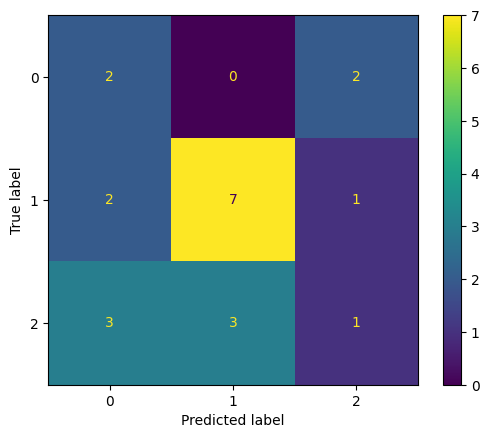

In [27]:
cm_slim = confusion_matrix(y_test_multinom, model_slim.predict(X_test_multinom_df[rf_top_200_genes]))
disp = ConfusionMatrixDisplay(cm_slim)

disp.plot()
plt.show()

The Random Forest model may have become biased and performed well by memorising instead of learning generalised patterns for the disease. Or, the remmoved features collectively were important for the model to perform well.

The model retraining will now be redone from feature selection step using an ensemble approach, to see if that improves performance.

###**Ensemble approach**

In [30]:
rf_ensemble = RandomForestClassifier(n_estimators = 100, class_weight = 'balanced', random_state = 42)
rf_ensemble.fit(X_train_multinom_df, y_train_multinom)

# Extracting feature importance
rf_ensemble_importance_df = pd.DataFrame({'Gene':gene_names, 'RF_importance':rf_ensemble.feature_importances_}).sort_values(by='RF_importance', ascending=False)

In [31]:
top_500_rf = rf_ensemble_importance_df.head(500)['Gene'].tolist()

In [32]:
# Performing L1 regularisation for feature selection

l1_selector = LogisticRegression(penalty = 'l1', solver = 'liblinear', C = 0.1, class_weight = 'balanced')
l1_selector.fit(X_train_multinom_df[top_500_rf], y_train_multinom)

LogisticRegression(C=0.1, class_weight='balanced', penalty='l1',
                   solver='liblinear')

In [40]:
print(f'Shape of L1 model coefficients: {l1_selector.coef_.shape}')

# Creating a mask for genes where weights are non-zero (True)
consensus_mask = (l1_selector.coef_ != 0).any(axis=0)     # checking for values across each row
final_genes = np.array(top_500_rf)[consensus_mask]

print(f'Final number of selected genes are {len(final_genes)}')

Shape of L1 model coefficients: (3, 500)
Final number of selected genes are 77


In [42]:
# Retraining the model on these selected robust genes

model_ensemble = LogisticRegression(class_weight = 'balanced', max_iter = 2000)
model_ensemble.fit(X_train_multinom_df[final_genes], y_train_multinom)

LogisticRegression(class_weight='balanced', max_iter=2000)

In [50]:
# Getting the performance metrics
ensemble_probs = model_ensemble.predict_proba(X_test_multinom_df[final_genes])
ensemble_auc = roc_auc_score(y_test_multinom, ensemble_probs, multi_class = 'ovr')

ensemble_acc = accuracy_score(y_test_multinom, model_ensemble.predict(X_test_multinom_df[final_genes]))*100
ensemble_report = classification_report(y_test_multinom, model_ensemble.predict(X_test_multinom_df[final_genes]))

print(f'Ensemble training report:\n')
print(f'AUC score: {ensemble_auc:.2f}')
print(f'Accuracy: {ensemble_acc:.2f}%')
print(f'Classification report:\n{ensemble_report}')

Ensemble training report:

AUC score: 0.67
Accuracy: 66.67%
Classification report:
              precision    recall  f1-score   support

           0       0.50      0.25      0.33         4
           1       0.71      1.00      0.83        10
           2       0.60      0.43      0.50         7

    accuracy                           0.67        21
   macro avg       0.60      0.56      0.56        21
weighted avg       0.64      0.67      0.63        21



###**Comparing genes with the ensemble model**

In [99]:
final_weights = l1_selector.coef_[:, consensus_mask]
ensemble_77 = pd.DataFrame({'Gene':final_genes, 'PD_weight':final_weights[1], 'Healthy_weight':final_weights[0], 'Other NDD weight':final_weights[2]})
ensemble_77.sort_values(by='PD_weight', ascending = False).head(20)

,Gene,PD_weight,Healthy_weight,Other NDD weight
21,211043_s_at,0.036733,-0.013124,0.000000
47,209508_x_at,0.034385,0.000000,-0.016330
52,214800_x_at,0.018957,0.008475,-0.024310
57,211509_s_at,0.014994,-0.016105,-0.002092
44,210401_at,0.014101,-0.001216,0.000000
67,201479_at,0.008414,0.000000,0.000000
39,208855_s_at,0.004733,0.000000,-0.001815
14,214109_at,0.004638,0.000000,0.000000
20,204220_at,0.003847,0.000470,-0.007766
4,40189_at,0.002492,0.003829,0.000000


In [91]:
# Getting top genes contributing to PD
ensemble_77_upreg30 = ensemble_77.sort_values(by = 'PD_weight', ascending = False).head(30)
ensemble_77_downreg30 = ensemble_77.sort_values(by = 'PD_weight', ascending = True).head(30)

In [92]:
binom_upreg30 = upreg_pd_genes.head(30)
binom_downreg30 = downreg_pd_genes.head(30)

In [93]:
# Finding common robust genes identified between the emsemble method and binomial regression

common_upreg_genes = set(ensemble_77_upreg30['Gene'].tolist()).intersection(set(binom_upreg30['Gene'].tolist()))
common_downreg_genes = set(ensemble_77_downreg30['Gene'].tolist()).intersection(set(binom_downreg30['Gene'].tolist()))

In [94]:
print(f'No. of common upregulated genes: {len(common_upreg_genes)}')
print(f'No. of common downregulated genes: {len(common_downreg_genes)}')

print(f'\nThe common up regulated genes: {common_upreg_genes}')
print(f'The common down regulated genes: {common_downreg_genes}')

No. of common upregulated genes: 3
No. of common downregulated genes: 1

The common up regulated genes: {'200926_at', '204446_s_at', '221700_s_at'}
The common down regulated genes: {'214022_s_at'}


These top genes seem like stable biomarkers to differentiate between PD and non-PD types across the different mathematical models for training. These will be taken forward for a breif variant analysis.